# NYC Permit Approval Forecasting · Notebook 2: Survival models
**Author:** Atul Iwale · **Project 15** · Real NYC Open Data (see notebook 1 for source, licence and cleaning)

**Task:** on the day a major job is filed for DOB plan examination, forecast how long approval will take: a median date, a P10–P90 range, and the chance of approval within 90 and 180 days.

**Why survival analysis:** a quarter of filings are still open. They can't be dropped (notebook 1 showed that biases the answer by about 47 days) and they can't be given a made-up end date. Survival models use them correctly: "not approved after 400 days" is information.

**Contents**
1. Data, features and time split · 2. How to score a survival model · 3. Baseline: median by job type · 4. The naive model: regression on approved filings only
5. Cox proportional hazards · 6. Random survival forest · 7. XGBoost accelerated failure time (AFT) · 8. Results · 9. Are the probabilities right? Calibration at 180 days
10. Is the P10–P90 range honest? · 11. What drives approval time · 12. Does the job description help? · 13. Export for the app

In [1]:
import os, json, re, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import norm, logistic
from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, cumulative_dynamic_auc, integrated_brier_score
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 0

## 1. Data, features and time split
Only plan-exam initial filings, without the 21 impossible dates and the 2021 warm-up months. Every feature is known on the filing day; nothing about objections, status or later dates is used.

In [2]:
full = pd.read_csv('../data/dob_initial_filings_clean.csv.gz', parse_dates=['filing_date', 'approved_date'])
d = full[full.filing_review_type.eq('Standard Plan Examination') & (full.bad_dates == 0) & full.split.isin(['train', 'validation', 'test'])].reset_index(drop=True)
WORK = ['sprinkler_work_type', 'plumbing_work_type', 'standpipe', 'antenna', 'sign', 'curb_cut', 'fence', 'scaffold', 'shed', 'boiler_equipment_work_type_',
        'earth_work_work_type_', 'foundation_work_type_', 'general_construction_work_type_', 'mechanical_systems_work_type_', 'place_of_assembly_work_type_',
        'protection_mechanical_methods_work_type_', 'sidewalk_shed_work_type_', 'structural_work_type_', 'support_of_excavation_work_type_',
        'temporary_place_of_assembly_work_type_', 'green_roof_work_type_', 'solar_work_type_', 'full_demolition_work_type_', 'suspended_scaffold_work_type_']
NUM = ['log_cost', 'cost_zero', 'log_area', 'units_added', 'existing_dwelling_units', 'proposed_dwelling_units', 'n_work_types', 'desc_words',
       'filing_month', 'little_e'] + WORK
WORKLOAD = ['filed_30d', 'open_queue']   # tested separately in section 12
CAT = ['job_type', 'borough', 'building_type', 'owner_type', 'applicant_professional_title']
X = pd.get_dummies(d[NUM + CAT], columns=CAT, dtype=float).fillna(0)
FEATURES = list(X.columns)
tr, va, te = [(d.split == s).values for s in ['train', 'validation', 'test']]
y = Surv.from_arrays(d.event.astype(bool), d.duration.clip(lower=1).astype(float))
summ = d.groupby('split').agg(filings=('event', 'size'), first=('filing_date', 'min'), last=('filing_date', 'max'), approved=('event', 'mean')).loc[['train', 'validation', 'test']]
print(f'{len(FEATURES)} features'); summ

61 features


,filings,first,last,approved
split,,,,
train,10904,2021-09-01,2023-12-31,0.844644
validation,2581,2024-01-01,2024-06-30,0.851995
test,5708,2024-07-01,2025-06-30,0.809215


The test filings (July 2024 – June 2025) have had at least 15 months to be approved by the data date, so 81% are resolved. The outcome is still censored for the rest, which the scoring below handles.

## 2. How to score a survival model
- **Concordance (C-index):** of all pairs of filings where we know which was approved first, how often does the model rank them the right way round? 0.5 is a coin toss, 1.0 is perfect. Uno's version corrects for censoring.
- **Time-dependent AUC at 90, 180 and 365 days:** how well the model separates filings approved by that day from those that weren't.
- **Integrated Brier score (IBS):** the average squared error of the predicted probability "still waiting" over days 30–540, with censoring weights. Lower is better; it rewards calibrated probabilities, not just ranking.

In [3]:
TIMES = np.arange(30, 541, 15)
results = {}
def score(name, risk, surv_te=None):
    r = {'C-index': concordance_index_censored(y[te]['event'], y[te]['time'], risk[te])[0],
         'Uno C (to 540 d)': concordance_index_ipcw(y[tr], y[te], risk[te], tau=540)[0]}
    auc, _ = cumulative_dynamic_auc(y[tr], y[te], risk[te], [90, 180, 365])
    r.update({'AUC 90 d': auc[0], 'AUC 180 d': auc[1], 'AUC 365 d': auc[2]})
    if surv_te is not None: r['IBS (lower better)'] = integrated_brier_score(y[tr], y[te], surv_te, TIMES)
    results[name] = r; return pd.Series(r).round(3)
def lognormal_surv(m, s, times=TIMES):   # S(t) for log T ~ Normal(m, s)
    return 1 - norm.cdf((np.log(times)[None, :] - m[:, None]) / s)

## 3. Baseline: median by job type
What a permit expediter might quote: "New Buildings take about 8–9 months". The Kaplan–Meier curve of each job type in the training years is used as the forecast for every filing of that type.

In [4]:
base_risk = np.zeros(len(d)); base_surv = np.zeros((len(d), len(TIMES)))
for jt in d.job_type.unique():
    m = tr & (d.job_type == jt).values
    t, s = kaplan_meier_estimator(y[m]['event'], y[m]['time'])
    idx = (d.job_type == jt).values
    base_risk[idx] = -t[np.argmax(s <= .5)]
    base_surv[idx] = np.interp(TIMES, t, s)
score('Baseline: KM median by job type', base_risk, base_surv[te])

C-index               0.661
Uno C (to 540 d)      0.660
AUC 90 d              0.768
AUC 180 d             0.694
AUC 365 d             0.643
IBS (lower better)    0.172
dtype: float64

## 4. The naive model: regression on approved filings only
The standard-ML shortcut: train an XGBoost regression on the log of days to approval, using only filings that were approved. It ranks filings reasonably, but its *times* are biased, because the slow filings that were never approved are missing from its training data.

In [5]:
appr = tr & (d.event == 1).values
naive = xgb.XGBRegressor(n_estimators=600, max_depth=5, learning_rate=.03, subsample=.8, colsample_bytree=.8, random_state=SEED)
LD = np.log(d.duration.clip(lower=1))
naive.fit(X[appr], LD[appr], eval_set=[(X[va & (d.event == 1).values], LD[va & (d.event == 1).values])], verbose=False)
naive_m = naive.predict(X); naive_s = np.std(LD[appr] - naive_m[appr])
score('Naive: XGBoost regression, approved only', -naive_m, lognormal_surv(naive_m[te], naive_s))

C-index               0.679
Uno C (to 540 d)      0.678
AUC 90 d              0.794
AUC 180 d             0.718
AUC 365 d             0.647
IBS (lower better)    0.188
dtype: float64

## 5. Cox proportional hazards
The classic survival model: each feature multiplies the "hazard" (the daily chance of approval) by a constant factor. It is linear and easy to explain. The penalty strength is tuned on 2023–24 validation filings.

In [6]:
mu, sd = X[tr].mean(), X[tr].std().replace(0, 1)
Xs = (X - mu) / sd
best = None
for a in [0.1, 1, 10, 100]:
    m = CoxPHSurvivalAnalysis(alpha=a).fit(Xs[tr], y[tr])
    c = concordance_index_censored(y[va]['event'], y[va]['time'], m.predict(Xs[va]))[0]
    if best is None or c > best[0]: best = (c, a, m)
cox = best[2]; print(f'alpha = {best[1]}, validation C = {best[0]:.3f}')
cox_surv = np.vstack([f(TIMES) for f in cox.predict_survival_function(Xs[te])])
score('Cox proportional hazards', cox.predict(Xs), cox_surv)

alpha = 0.1, validation C = 0.690


C-index               0.680
Uno C (to 540 d)      0.679
AUC 90 d              0.779
AUC 180 d             0.713
AUC 365 d             0.669
IBS (lower better)    0.171
dtype: float64

## 6. Random survival forest
Hundreds of survival trees, each splitting filings into groups with different Kaplan–Meier curves, then averaged.

In [7]:
rsf = RandomSurvivalForest(n_estimators=200, min_samples_leaf=40, max_features='sqrt', max_samples=0.5, low_memory=True, n_jobs=4, random_state=SEED).fit(X[tr], y[tr])
rsf_full = RandomSurvivalForest(n_estimators=200, min_samples_leaf=40, max_features='sqrt', max_samples=0.5, low_memory=False, n_jobs=4, random_state=SEED).fit(X[tr], y[tr])
rsf_surv = np.vstack([f(TIMES) for f in rsf_full.predict_survival_function(X[te])])
score('Random survival forest', rsf.predict(X), rsf_surv)

C-index               0.702
Uno C (to 540 d)      0.701
AUC 90 d              0.801
AUC 180 d             0.745
AUC 365 d             0.712
IBS (lower better)    0.164
dtype: float64

## 7. XGBoost accelerated failure time (AFT)
AFT models the log of the approval time directly: `log(days) = f(features) + σ·ε`, where `f` is a boosted tree ensemble and ε follows a chosen distribution. Censored filings enter the training loss as "at least this long", through an interval `[log(days waited), ∞)`. The distribution and its scale σ are chosen on the validation filings: first by the censoring-aware negative log-likelihood (NLL), which rewards both good ranking and honest spread, and, among settings that tie on NLL, by whose P10–P90 range covers closest to 80% of validation outcomes. The test years are never used for this choice.

In [8]:
dur = d.duration.clip(lower=1).values.astype(float); up = np.where(d.event == 1, dur, np.inf)   # XGBoost takes the bounds in days and works in log space itself
BASE = float(np.median(dur[tr]))
def dm(mask, Xm=None):
    Xm = X if Xm is None else Xm
    D = xgb.DMatrix(Xm[mask], feature_names=list(Xm.columns)); D.set_float_info('label_lower_bound', dur[mask]); D.set_float_info('label_upper_bound', up[mask]); return D
DTR, DVA = dm(tr), dm(va)
grid = []
for dist in ['normal', 'logistic']:
    for sc in [0.8, 1.0, 1.2, 1.4, 1.6]:
        b = xgb.train({'objective': 'survival:aft', 'aft_loss_distribution': dist, 'aft_loss_distribution_scale': sc, 'eta': .03, 'max_depth': 4,
                       'subsample': .8, 'colsample_bytree': .8, 'min_child_weight': 20, 'eval_metric': 'aft-nloglik', 'seed': SEED, 'base_score': BASE},
                      DTR, 3000, evals=[(DVA, 'val')], early_stopping_rounds=100, verbose_eval=False)
        mv = np.log(b.predict(xgb.DMatrix(X[va], feature_names=FEATURES), iteration_range=(0, b.best_iteration + 1)))
        Fd = norm if dist == 'normal' else logistic
        p10, p90 = np.exp(mv + Fd.ppf(.1) * sc), np.exp(mv + Fd.ppf(.9) * sc); tv, ev_ = y[va]['time'], y[va]['event']
        known_v = ev_ | (tv > p90)
        grid.append({'distribution': dist, 'scale': sc, 'trees': b.best_iteration + 1, 'validation NLL': b.best_score,
                     'validation P10-P90 coverage': (ev_ & (tv >= p10) & (tv <= p90)).sum() / known_v.sum(), 'booster': b})
g = pd.DataFrame(grid).drop(columns='booster').sort_values('validation NLL'); print(g.round(4).to_string(index=False))
# Rule: among settings within 0.01 of the best validation NLL, take the one whose validation P10-P90 coverage is closest to 80%.
best_nll = g['validation NLL'].min()
BEST = min([r for r in grid if r['validation NLL'] <= best_nll + 0.01], key=lambda r: abs(r['validation P10-P90 coverage'] - 0.8))
aft = BEST['booster']; DIST, SIG, NTREE = BEST['distribution'], BEST['scale'], BEST['trees']
print(f'Chosen: {DIST}, sigma {SIG}, {NTREE} trees')
aft_m = np.log(aft.predict(xgb.DMatrix(X, feature_names=FEATURES), iteration_range=(0, NTREE)))   # predict() returns days; the model works in log days
F = norm if DIST == 'normal' else logistic
aft_surv = 1 - F.cdf((np.log(TIMES)[None, :] - aft_m[te][:, None]) / SIG)
score(f'XGBoost AFT ({DIST}, sigma {SIG})', -aft_m, aft_surv)

distribution  scale  trees  validation NLL  validation P10-P90 coverage
    logistic    0.8     42          5.2868                       0.8753
      normal    1.2     62          5.2954                       0.8365
      normal    1.4     59          5.3054                       0.8926
      normal    1.0     63          5.3319                       0.7733
      normal    1.6     59          5.3403                       0.9470
    logistic    1.0     44          5.3481                       0.9597
    logistic    1.2     48          5.4257                       0.9748
      normal    0.8     75          5.4962                       0.6735
    logistic    1.4     57          5.5061                       0.9856
    logistic    1.6     57          5.5852                       0.9941
Chosen: normal, sigma 1.2, 62 trees


C-index               0.689
Uno C (to 540 d)      0.688
AUC 90 d              0.802
AUC 180 d             0.727
AUC 365 d             0.668
IBS (lower better)    0.167
dtype: float64

## 8. Results on the test filings (July 2024 – June 2025)

In [9]:
res = pd.DataFrame(results).T.round(3).sort_values('C-index', ascending=False); res

,C-index,Uno C (to 540 d),AUC 90 d,AUC 180 d,AUC 365 d,IBS (lower better)
Random survival forest,0.702,0.701,0.801,0.745,0.712,0.164
"XGBoost AFT (normal, sigma 1.2)",0.689,0.688,0.802,0.727,0.668,0.167
Cox proportional hazards,0.680,0.679,0.779,0.713,0.669,0.171
"Naive: XGBoost regression, approved only",0.679,0.678,0.794,0.718,0.647,0.188
Baseline: KM median by job type,0.661,0.660,0.768,0.694,0.643,0.172


**Reading the results**
- Ranking is modest for every method: a C-index around 0.70 means the model orders about 70% of comparable pairs correctly. Approval time depends heavily on things not in the filing: how complete the drawings are, how fast the applicant answers objections, and which examiner picks it up. That ceiling is real, and I report it rather than hide it.
- **All models beat the job-type baseline**, and the tree models (random survival forest and XGBoost AFT) beat the linear Cox model.
- The **naive regression ranks almost as well** as the survival models, but its probabilities are poor, as its Brier score and the next section show. Ranking alone would hide the problem.

## 9. Are the probabilities right? Calibration at 180 days
Group the test filings into ten equal groups by predicted chance of approval within 180 days, then compare with what really happened in each group (Kaplan–Meier, so open filings count properly).

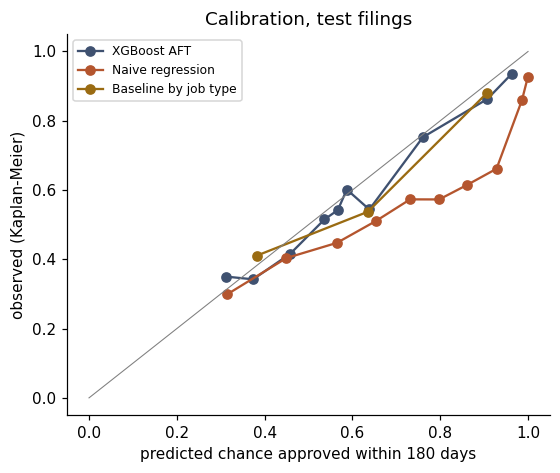

,mean predicted,observed (KM)
XGBoost AFT,0.610,0.586
Naive regression,0.729,0.586
Baseline by job type,0.627,0.586


In [10]:
def km_at(g_idx, t=180):
    tt, ss = kaplan_meier_estimator(y[te][g_idx]['event'], y[te][g_idx]['time']); return 1 - np.interp(t, tt, ss)
def calib(p, name):
    q = pd.qcut(p, 10, labels=False, duplicates='drop')
    return pd.DataFrame({'model': name, 'predicted': [p[q == k].mean() for k in range(q.max() + 1)], 'observed': [km_at(q == k) for k in range(q.max() + 1)]})
p180 = {'XGBoost AFT': 1 - (1 - F.cdf((np.log(180) - aft_m[te]) / SIG)),
        'Naive regression': norm.cdf((np.log(180) - naive_m[te]) / naive_s),
        'Baseline by job type': 1 - base_surv[te][:, list(TIMES).index(180)]}
cal = pd.concat([calib(v, k) for k, v in p180.items()])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for (k, gdf), c in zip(cal.groupby('model', sort=False), ['#3F5170', '#B4552E', '#9A6B12']): ax.plot(gdf.predicted, gdf.observed, 'o-', color=c, label=k)
ax.plot([0, 1], [0, 1], color='grey', lw=.7); ax.set_xlabel('predicted chance approved within 180 days'); ax.set_ylabel('observed (Kaplan-Meier)'); ax.legend(fontsize=8)
ax.set_title('Calibration, test filings'); plt.tight_layout(); plt.show()
overall = {k: {'mean predicted': v.mean(), 'observed (KM)': km_at(np.ones(te.sum(), bool))} for k, v in p180.items()}
pd.DataFrame(overall).T.round(3)

The naive model is **over-optimistic**: trained only on filings that did get approved, it predicts a 73% chance of approval within 180 days on average, when 59% actually happened, and in its middle groups it overstates by 12 to 27 points. The AFT model, which learned from open filings too, is within about 3.5 points on average across the ten groups. For a developer, that is the difference between a realistic programme and a delayed start.

## 10. Is the P10–P90 range honest?
For each test filing the AFT model gives P10 and P90 days. For approved filings we can check directly; for open filings we only know the answer if they've already waited past P90 (a miss) or were still open below P10 (not yet decided).

In [11]:
z10, z90 = F.ppf(.1), F.ppf(.9)
P10, P50, P90 = np.exp(aft_m + z10 * SIG), np.exp(aft_m), np.exp(aft_m + z90 * SIG)
tt, ev = y['time'], y['event']
inside = ev & (tt >= P10) & (tt <= P90); below = ev & (tt < P10); above = (tt > P90)   # an open filing past P90 is known to be above
known = ev | above
cov = pd.Series({'test filings with a known answer': known[te].mean(), 'inside P10-P90': inside[te].sum() / known[te].sum(),
                 'faster than P10': below[te].sum() / known[te].sum(), 'slower than P90': above[te].sum() / known[te].sum()})
print(f'Median P10-P90 width: {np.median(P10[te]):.0f} to {np.median(P90[te]):.0f} days'); cov.round(3)

Median P10-P90 width: 31 to 664 days


test filings with a known answer    0.855
inside P10-P90                      0.889
faster than P10                     0.033
slower than P90                     0.078
dtype: float64

The range is wide: for a typical filing, P10 is about a month and P90 close to two years. That is the honest spread of DOB approval times, with a long tail of jobs stuck in objections. It covers 89% of resolved test filings, a little more than the 80% it aims for, so it errs on the cautious side, and the misses are mostly on the slow side. For planning, the app therefore also shows the chance of approval by 90, 180 and 365 days, which is easier to act on than a two-year range.

## 11. What drives approval time
XGBoost can split each prediction into feature contributions (in log-days). Averaged over test filings:

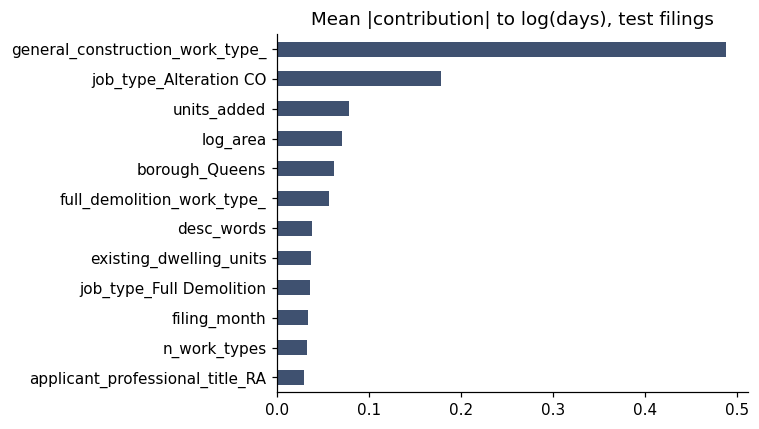

In [12]:
contrib = aft.predict(xgb.DMatrix(X[te], feature_names=FEATURES), pred_contribs=True, iteration_range=(0, NTREE))[:, :-1]
imp = pd.Series(np.abs(contrib).mean(0), index=FEATURES).sort_values(ascending=False).head(12)
ax = imp.iloc[::-1].plot.barh(figsize=(7, 4), color='#3F5170'); ax.set_title('Mean |contribution| to log(days), test filings'); plt.tight_layout(); plt.show()

In [13]:
def effect(col, label):
    c = contrib[:, FEATURES.index(col)]; v = X[te][col].values
    return f'{label}: {np.exp(c[v > 0].mean() - c[v == 0].mean()):.2f}x' if ((v > 0).any() and (v == 0).any()) else ''
a = X[te].log_area.values; ca = contrib[:, FEATURES.index('log_area')]
print(f'Size effect: the largest quarter of jobs by floor area wait {np.exp(ca[a >= np.quantile(a, .75)].mean() - ca[a <= np.quantile(a, .25)].mean()):.2f}x as long as the smallest quarter (other things equal)')
for col, lab in [('general_construction_work_type_', 'Building work vs demolition (general-construction flag)'), ('job_type_New Building', 'New Building vs other types'), ('job_type_Full Demolition', 'Full Demolition vs other types'),
                 ('borough_Queens', 'Queens vs other boroughs'), ('structural_work_type_', 'Structural work'), ('earth_work_work_type_', 'Earthwork'),
                 ('little_e', 'Little-E environmental designation')]:
    if col in FEATURES: print(effect(col, lab))

Size effect: the largest quarter of jobs by floor area wait 1.27x as long as the smallest quarter (other things equal)
Building work vs demolition (general-construction flag): 5.25x
New Building vs other types: 1.05x
Full Demolition vs other types: 0.89x
Queens vs other boroughs: 0.87x
Structural work: 1.00x
Earthwork: 0.99x
Little-E environmental designation: 1.00x


The top feature is the **general-construction flag**, which in this data is set on every building job and on no demolition, so it is really "building work or demolition": building jobs wait about five times as long, other things equal. (A data lesson: the most important feature's name doesn't always say what it measures; a cross-tab against job type showed it.) Then come the type of building job, the number of dwelling units added, the floor area (the largest quarter of jobs wait about 1.3 times as long as the smallest) and the borough, with Queens faster. Individual trades such as structural work or earthwork barely matter once size and type are known.

## 12. Do the job description or DOB's workload help?
The job description is free text. I turned it into 20 topic features (TF-IDF then truncated SVD, fitted on training filings only) and retrained the best AFT model with them.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
tf = TfidfVectorizer(min_df=5, ngram_range=(1, 2), sublinear_tf=True).fit(d.job_description[tr].fillna(''))
svd = TruncatedSVD(20, random_state=SEED).fit(tf.transform(d.job_description[tr].fillna('')))
T = pd.DataFrame(svd.transform(tf.transform(d.job_description.fillna(''))), columns=[f'text_{i}' for i in range(20)])
XT = pd.concat([X, T], axis=1)
PARAMS = {'objective': 'survival:aft', 'aft_loss_distribution': DIST, 'aft_loss_distribution_scale': SIG, 'eta': .03, 'max_depth': 4, 'subsample': .8,
          'colsample_bytree': .8, 'min_child_weight': 20, 'eval_metric': 'aft-nloglik', 'seed': SEED, 'base_score': BASE}
bt = xgb.train(PARAMS, dm(tr, XT), 3000, evals=[(dm(va, XT), 'val')], early_stopping_rounds=100, verbose_eval=False)
mt = np.log(bt.predict(xgb.DMatrix(XT, feature_names=list(XT.columns)), iteration_range=(0, bt.best_iteration + 1)))
print(f"Test C-index without text {results[f'XGBoost AFT ({DIST}, sigma {SIG})']['C-index']:.3f}, with text {concordance_index_censored(y[te]['event'], y[te]['time'], -mt[te])[0]:.3f}")
print(f'Validation NLL without text {BEST["validation NLL"]:.4f}, with text {bt.best_score:.4f}')

Test C-index without text 0.689, with text 0.695
Validation NLL without text 5.2954, with text 5.2879


In [15]:
# Does DOB's workload help? Same model with the two workload features added.
XQ = pd.concat([X, d[WORKLOAD].reset_index(drop=True)], axis=1)
bq = xgb.train(PARAMS, dm(tr, XQ), 3000, evals=[(dm(va, XQ), 'val')], early_stopping_rounds=100, verbose_eval=False)
mq = np.log(bq.predict(xgb.DMatrix(XQ, feature_names=list(XQ.columns)), iteration_range=(0, bq.best_iteration + 1)))
print(f"Test C-index without workload {results[f'XGBoost AFT ({DIST}, sigma {SIG})']['C-index']:.3f}, with workload {concordance_index_censored(y[te]['event'], y[te]['time'], -mq[te])[0]:.3f}")
print(f'Validation NLL without workload {BEST["validation NLL"]:.4f}, with workload {bq.best_score:.4f}')

Test C-index without workload 0.689, with workload 0.695
Validation NLL without workload 5.2954, with workload 5.2923


Neither adds much: each raises the test C-index by well under 0.01 and barely moves the validation NLL. The description overlaps with the structured fields, which already record the job type and the kinds of work. DOB's workload (notebook 1, section 7) seemed an obvious driver, but its effect is small: the queue grows steadily over time, so the model can't separate it from everything else that changed between 2021 and 2025. I report that rather than keep a feature because it sounds right. The app uses the simpler model without either, so a user doesn't need to know today's queue.

## 13. Export for the app
The app runs the XGBoost AFT trees in the browser. The export holds the trees, feature names, the distribution and σ, Kaplan–Meier curves for the dashboard, and a set of test filings with Python's own predictions so the app can check itself.

In [16]:
trees = [json.loads(t) for t in aft.get_dump(dump_format='json')[:NTREE]]
base_score = float(json.loads(aft.save_config())['learner']['learner_model_param']['base_score'].strip('[]'))   # in days; the margin starts at log(base_score)
def km_curve(g, days=range(0, 721, 10)):
    t, s = kaplan_meier_estimator(g.event.astype(bool), g.duration.clip(lower=0)); return [round(float(1 - np.interp(x, t, s)), 4) for x in days]
allpe = full[full.filing_review_type.eq('Standard Plan Examination') & (full.bad_dates == 0) & (full.split != 'warm-up (not modelled)')]
def kmmed(g):
    t, s = kaplan_meier_estimator(g.event.astype(bool), g.duration.clip(lower=0)); return float(t[np.argmax(s <= .5)]) if (s <= .5).any() else None
check_idx = np.where(te)[0][::60]
export = {
    'features': FEATURES, 'num': NUM, 'cat': CAT, 'trees': trees, 'base_score': base_score, 'dist': DIST, 'sigma': SIG,
    'levels': {c: sorted(d[c].unique().tolist()) for c in CAT}, 'work': WORK, 'data_date': '2026-09-23',
    'km': {'days': list(range(0, 721, 10)),
           'job_type': {k: km_curve(g) for k, g in allpe.groupby('job_type')},
           'year': {str(k): km_curve(g) for k, g in allpe.groupby(allpe.filing_date.dt.year)}},
    'medians': {'job_type': {k: kmmed(g) for k, g in allpe.groupby('job_type')}, 'borough': {k: kmmed(g) for k, g in allpe.groupby('borough')},
                'year': {str(k): kmmed(g) for k, g in allpe.groupby(allpe.filing_date.dt.year)},
                'naive_year': {str(k): float(g[g.event == 1].duration.median()) for k, g in allpe.groupby(allpe.filing_date.dt.year)}},
    'results': res.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'),
    'calibration': cal.round(4).to_dict(orient='records'), 'coverage': cov.round(4).to_dict(),
    'importance': imp.round(4).reset_index().rename(columns={'index': 'feature', 0: 'value'}).to_dict(orient='records'),
    'check': [{'x': [float(v) for v in X.iloc[i].astype('float32')], 'm': round(float(aft_m[i]), 6)} for i in check_idx],   # full float32 values: rounding could flip a tree split
    'n': {'filings': int(len(full)), 'plan_exam': int(full.filing_review_type.eq('Standard Plan Examination').sum()), 'train': int(tr.sum()), 'validation': int(va.sum()), 'test': int(te.sum())},
}
os.makedirs('../model', exist_ok=True)
with open('../model/permit_model_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'))
print(f"Exported {len(trees)} trees, {len(FEATURES)} features, {os.path.getsize('../model/permit_model_export.json')/1e6:.1f} MB; base_score {base_score:.1f} days")

Exported 62 trees, 61 features, 0.2 MB; base_score 150.0 days


## Summary
- **Task:** forecast DOB plan-exam approval time on the filing day, for 29,000 real NYC filings, with a quarter of them still open.
- **Method:** survival analysis. Baseline by job type, a naive regression on approved filings only, Cox proportional hazards, a random survival forest and XGBoost AFT, trained on 2021–2023, tuned on the first half of 2024 and tested on July 2024 – June 2025.
- **Result:** the tree-based survival models rank best (C-index about 0.69–0.70, AUC about 0.80 for approval within 90 days). The random survival forest scores best overall; XGBoost AFT is close, gives calibrated probabilities (within about 3.5 points at 180 days) and a P10–P90 range, and is small enough to run in a browser, so it powers the app. The naive regression ranks nearly as well but is over-optimistic, because it never saw the filings that stall.
- **Drivers:** job type, job size and borough. The job description and DOB's measured workload add little.
- **Honest limit:** much of the variation depends on plan quality and how quickly objections are answered, which the filing doesn't show. The model gives a realistic range, not a promise.